# Predicting Health Insurance Charges

I'm using a health insurance dataset to look at what affects how much someone gets charged, and then building a regression model to predict charges for new people.

## About the data

`insurance.csv` has 1,338 rows, one per person:

| Column | What it is |
|---|---|
| `age` | age of the person |
| `sex` | male or female |
| `bmi` | body mass index |
| `children` | number of dependents |
| `smoker` | yes or no |
| `region` | which US region |
| `charges` | what they were billed (this is what I'm predicting) |

The raw file has a few issues (missing values, inconsistent spelling, etc.) that I clean up first. `validation_dataset.csv` has the same columns except `charges` -- I use it at the end to see what the model predicts for some new people.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import shapiro, mannwhitneyu, kruskal

sns.set_style('whitegrid')

insurance = pd.read_csv('insurance.csv')
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924
1,18.0,male,33.770,1.0,no,Southeast,1725.5523
2,28.0,male,33.000,3.0,no,southeast,$4449.462
3,33.0,male,22.705,0.0,no,northwest,$21984.47061
4,32.0,male,28.880,0.0,no,northwest,$3866.8552


## 1. Cleaning the Data

Checking the raw file first, I found:
- missing values in most columns
- `sex` and `region` spelled inconsistently (`'F'` vs `'female'`, `'Southeast'` vs `'southeast'`)
- `charges` stored as text, with a `$` sign on some rows
- some negative values in `age` / `bmi` / `children`, which obviously can't be right

Fixing all of this below.

In [2]:
print(insurance.isna().sum())
print(f"\nrows before: {len(insurance)}")

# drop rows with missing data -- not too many rows lost, so this should be fine
insurance_clean = insurance.dropna().copy()
print(f"rows after: {len(insurance_clean)}")

# region had different capitalizations
insurance_clean['region'] = insurance_clean['region'].str.lower()

# sex had a few different spellings for the same two categories
sex_map = {'F': 'female', 'woman': 'female', 'man': 'male', 'M': 'male'}
insurance_clean['sex'] = insurance_clean['sex'].replace(sex_map)

# turning smoker into True/False instead of yes/no
insurance_clean['smoker'] = (insurance_clean['smoker'] == 'yes')

# charges is text and has a $ on some rows, so stripping that and converting to a number
insurance_clean['charges'] = insurance_clean['charges'].astype(str).str.strip('$').astype('float64')

# checking again for nulls -- converting to float can create new ones.
# found one row where charges was literally the text "$nan", which becomes
# a real NaN once converted. dropna() at the top didn't catch this since it
# looked like normal text at the time.
if insurance_clean['charges'].isna().sum() > 0:
    print("found a hidden null after converting charges to numbers, dropping it")
    insurance_clean = insurance_clean.dropna(subset=['charges'])

# age/bmi/children can't be negative, so this is probably just a sign error -- taking abs value
numeric_cols = insurance_clean.select_dtypes(include=np.number).columns
insurance_clean[numeric_cols] = insurance_clean[numeric_cols].abs()

insurance_clean.sample(5, random_state=1)

age         66
sex         66
bmi         66
children    66
smoker      66
region      66
charges     54
dtype: int64

rows before: 1338
rows after: 1208
found a hidden null after converting charges to numbers, dropping it


,age,sex,bmi,children,smoker,region,charges
217,27.0,male,23.100,0.0,False,southeast,2483.73600
644,43.0,male,35.310,2.0,False,southeast,18806.14547
905,26.0,female,29.355,2.0,False,northeast,4564.19145
1000,30.0,male,22.990,2.0,True,northwest,17361.76610
373,26.0,male,32.900,2.0,True,southwest,36085.21900


## 2. Exploring the Data

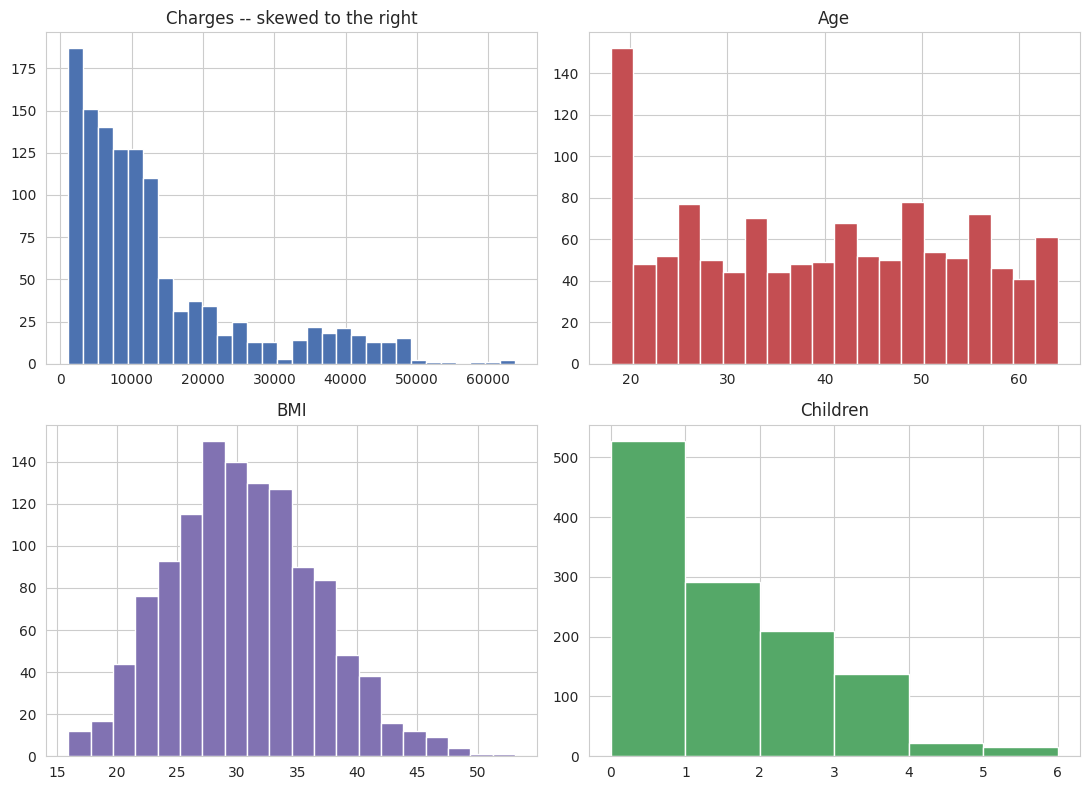

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(insurance_clean['charges'], bins=30, color='#4C72B0')
axes[0, 0].set_title('Charges -- skewed to the right')

axes[0, 1].hist(insurance_clean['age'], bins=20, color='#C44E52')
axes[0, 1].set_title('Age')

axes[1, 0].hist(insurance_clean['bmi'], bins=20, color='#8172B2')
axes[1, 0].set_title('BMI')

axes[1, 1].hist(insurance_clean['children'], bins=range(7), color='#55A868')
axes[1, 1].set_title('Children')

plt.tight_layout()
plt.show()

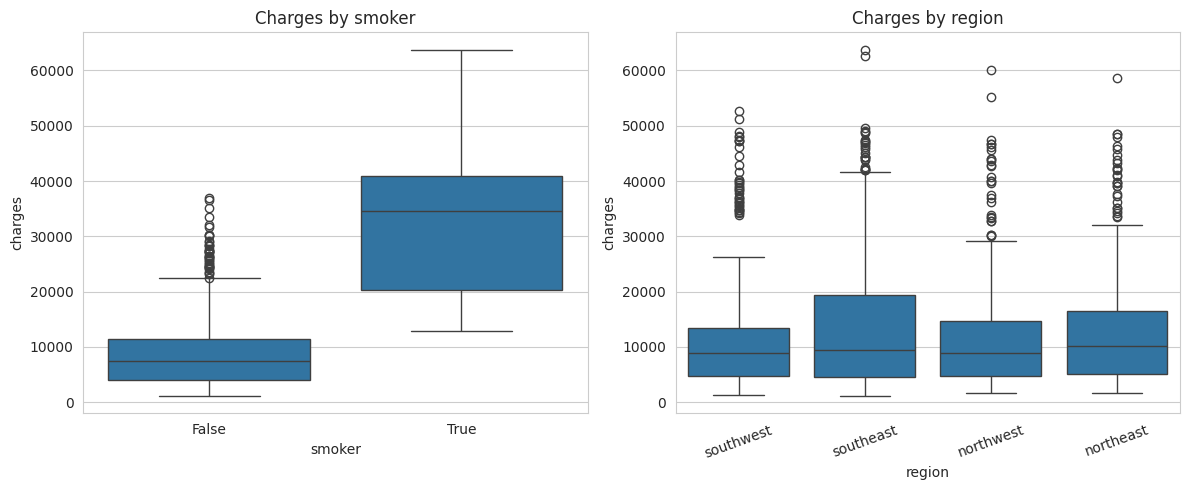

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=insurance_clean, x='smoker', y='charges', ax=axes[0])
axes[0].set_title('Charges by smoker')

sns.boxplot(data=insurance_clean, x='region', y='charges', ax=axes[1])
axes[1].set_title('Charges by region')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

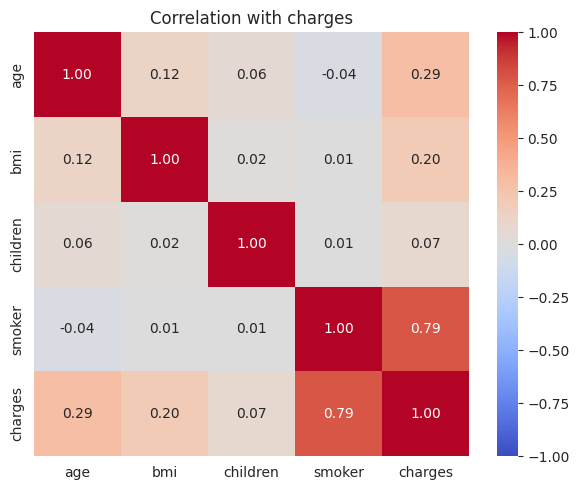

charges     1.000000
smoker      0.785997
age         0.291875
bmi         0.199039
children    0.071256
Name: charges, dtype: float64

In [5]:
corr_df = insurance_clean.copy()
corr_df['smoker'] = corr_df['smoker'].astype(int)

corr = corr_df[['age', 'bmi', 'children', 'smoker', 'charges']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation with charges')
plt.tight_layout()
plt.show()

corr['charges'].sort_values(ascending=False)

### Does BMI matter more for smokers?

The correlation table says `bmi` only has a weak relationship with charges (0.2ish) on its own. But I wondered if it matters a lot more specifically for smokers, so I plotted `bmi` vs `charges`, colored by smoking status.

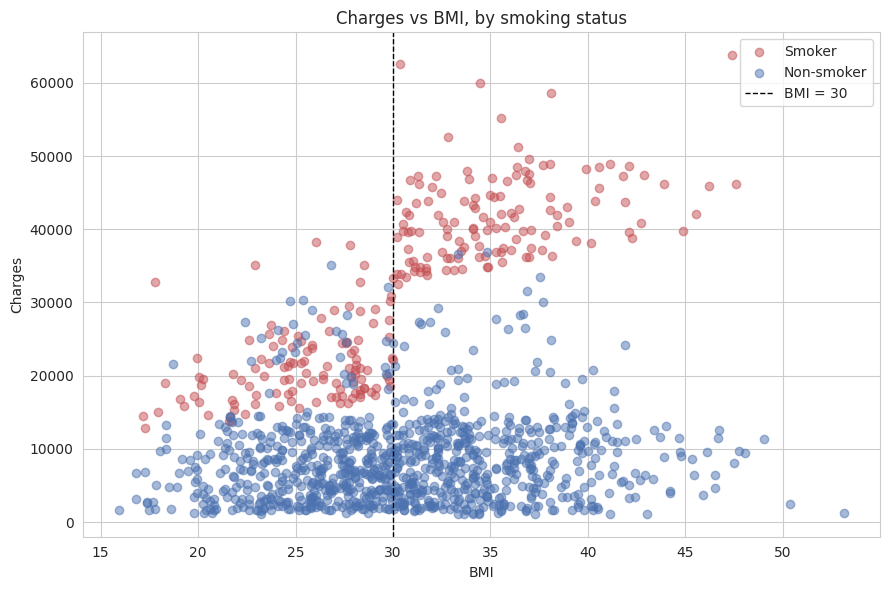

In [6]:
plt.figure(figsize=(9, 6))

for is_smoker, color, label in [(True, '#C44E52', 'Smoker'), (False, '#4C72B0', 'Non-smoker')]:
    subset = insurance_clean[insurance_clean['smoker'] == is_smoker]
    plt.scatter(subset['bmi'], subset['charges'], alpha=0.5, color=color, label=label)

plt.axvline(30, color='black', linestyle='--', linewidth=1, label='BMI = 30')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title('Charges vs BMI, by smoking status')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Checking if the Differences are Real

The boxplots show smokers pay a lot more, and maybe region matters a bit. But a plot alone isn't proof, so I ran some tests.

Normally you'd use a t-test / ANOVA for this, but those assume the data is roughly normal, and we already saw `charges` is pretty skewed. So I used the non-parametric versions instead (Mann-Whitney U, Kruskal-Wallis), which don't need that assumption. Checked with Shapiro-Wilk first just to be sure charges really isn't normal.

In [7]:
stat, p = shapiro(insurance_clean['charges'])
print(f"Shapiro-Wilk p-value: {p:.2e}")
# very small p-value -> charges is NOT normally distributed

Shapiro-Wilk p-value: 3.51e-35


In [8]:
smoker_charges = insurance_clean.loc[insurance_clean['smoker'], 'charges']
nonsmoker_charges = insurance_clean.loc[~insurance_clean['smoker'], 'charges']

u_stat, p_value = mannwhitneyu(smoker_charges, nonsmoker_charges)
print(f"p-value: {p_value:.2e}")
print(f"median charges -- smokers: {smoker_charges.median():.0f}, non-smokers: {nonsmoker_charges.median():.0f}")

p-value: 9.70e-118
median charges -- smokers: 34545, non-smokers: 7419


In [9]:
region_groups = [g['charges'].values for _, g in insurance_clean.groupby('region')]

h_stat, p_value_region = kruskal(*region_groups)
print(f"p-value: {p_value_region:.4f}")

p-value: 0.2028


**Interpretation:**
- Shapiro-Wilk gives a tiny p-value (3.5e-35), so charges really isn't normal -- good, that confirms non-parametric tests were the right call here.
- Mann-Whitney gives a p-value of basically 0 (9.7e-118) for smoker vs non-smoker, so that difference is definitely real. Smokers pay a median of \$34,545 vs \$7,419 for non-smokers.
- Kruskal-Wallis for region gives p = 0.20, which is above 0.05, so I can't say region makes a real difference here. Matches what the correlation table already showed (region barely correlated with charges).

## 4. Adding an Interaction 

From the bmi-vs-smoker plot, high bmi + smoking together seems to lead to much higher charges than either one alone. A plain linear model can't pick up on that kind of combo effect unless I give it a feature for it. So I added:

- `smoker_bmi` = `smoker` x `bmi`, so the model can learn a different bmi effect for smokers
- `bmi_30_flag` = 1 if bmi is 30 or higher (the usual "obese" cutoff), else 0

Also turned `region` into dummy columns (dropping one to avoid dummy variable problem) and `sex` into a single `is_male` column.

In [10]:
model_df = pd.get_dummies(insurance_clean, prefix='region', columns=['region'])
model_df = model_df.drop(columns=['region_southeast'])  # baseline region

model_df['smoker'] = model_df['smoker'].astype('int64')
model_df['is_male'] = (model_df['sex'] == 'male').astype('int64')
model_df = model_df.drop(columns=['sex'])

model_df['smoker_bmi'] = model_df['smoker'] * model_df['bmi']
model_df['bmi_30_flag'] = (model_df['bmi'] >= 30).astype('int64')

model_df = model_df.dropna()
model_df.head()

,age,bmi,children,smoker,charges,region_northeast,region_northwest,region_southwest,is_male,smoker_bmi,bmi_30_flag
0,19.0,27.900,0.0,1,16884.92400,False,False,True,0,27.9,0
1,18.0,33.770,1.0,0,1725.55230,False,False,False,1,0.0,1
2,28.0,33.000,3.0,0,4449.46200,False,False,False,1,0.0,1
3,33.0,22.705,0.0,0,21984.47061,False,True,False,1,0.0,0
4,32.0,28.880,0.0,0,3866.85520,False,True,False,1,0.0,0


## 5. Building the Model

Comparing two versions:
- **Model A**: just the original features
- **Model B**: same as A, plus the two new features from above

Splitting into train/test first so I can check how well each one predicts on data it hasn't seen.

In [11]:
new_cols = ['smoker_bmi', 'bmi_30_flag']
all_cols = [c for c in model_df.columns if c != 'charges']
baseline_cols = [c for c in all_cols if c not in new_cols]

X = model_df[all_cols]
y = model_df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


def fit_and_score(feature_cols):
    model = LinearRegression()
    model.fit(X_train[feature_cols], y_train)
    pred = model.predict(X_test[feature_cols])
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    return model, r2, rmse, mae, pred


model_a, r2_a, rmse_a, mae_a, pred_a = fit_and_score(baseline_cols)
model_b, r2_b, rmse_b, mae_b, pred_b = fit_and_score(all_cols)

print(f"Model A -- R2: {r2_a:.3f}, RMSE: {rmse_a:.0f}, MAE: {mae_a:.0f}")
print(f"Model B -- R2: {r2_b:.3f}, RMSE: {rmse_b:.0f}, MAE: {mae_b:.0f}")

Model A -- R2: 0.705, RMSE: 6320, MAE: 4379
Model B -- R2: 0.842, RMSE: 4617, MAE: 2721


In [12]:
coefs = pd.Series(model_b.coef_, index=all_cols).sort_values(key=abs, ascending=False)
coefs

smoker             -20301.056606
bmi_30_flag          2904.930629
smoker_bmi           1444.469561
region_northeast      870.577581
is_male              -531.125244
children              505.964047
region_northwest      487.929665
age                   269.821417
bmi                  -183.657007
region_southwest     -139.516421
dtype: float64

**What this means:**
- Model B is a clear improvement -- adding the two new features took R square from 0.705 to 0.842, and cut RMSE from \$6,320 to \$4,617. So the "bmi matters more for smokers" idea from the scatter plot actually helps.
- The `smoker` coefficient in Model B looks weirdly negative (-\$20,301) at first glance. That's because with the interaction term in the model, `smoker` by itself is only the effect when bmi = 0, which never actually happens in the data. The real effect of smoking = smoker_coef + smoker_bmi_coef * bmi. At an average bmi of about 30.6, that works out to roughly \$23,860 -- which lines up a lot better with the \$27k gap we saw in the medians earlier.

## 6. Checking the Model's Assumptions

A good R sqaure doesn't automatically mean the model is doing everything right. Two things worth checking on Model B:
- do the errors stay about the same size across all predictions, or get bigger for bigger ones? (homoscedasticity)
- are the errors roughly normally distributed?

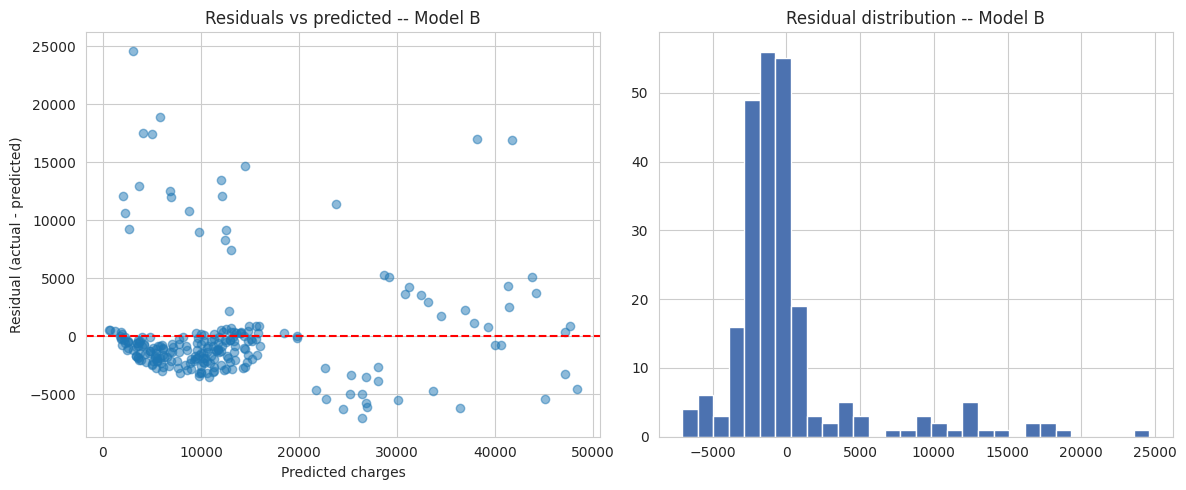

In [13]:
residuals_b = y_test - pred_b

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(pred_b, residuals_b, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted charges')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].set_title('Residuals vs predicted -- Model B')

axes[1].hist(residuals_b, bins=30, color='#4C72B0')
axes[1].set_title('Residual distribution -- Model B')

plt.tight_layout()
plt.show()

**What this means:**
- Model B is noticeably better at the correlation between predicted value and error size drops from 0.51 (Model A) to 0.15 (Model B). So the new features helped with that.
- But the errors are still not very normal infact the skew got a bit worse (1.18 to 2.54), and a Shapiro-Wilk test on the residuals still rejects normality pretty strongly. So Model B isn't perfect, it just fixed one of the two problems. Something to try later would be log-transforming charges, since that specifically targets the normality issue.

## 7. Which Features Actually Matter

The coefficients from Model B are just point estimates -- they don't tell me if a feature's effect is real or could just be random noise. So I refit the same model using `statsmodels`, which gives a p-value for each feature.

In [14]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_train[all_cols].astype(float))
ols_model = sm.OLS(y_train, X_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     523.7
Date:                Sun, 02 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:32:57   Log-Likelihood:                -9550.8
No. Observations:                 965   AIC:                         1.912e+04
Df Residuals:                     954   BIC:                         1.918e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1312.6367   1377.901  

In [15]:
sig_table = pd.DataFrame({
    'coefficient': ols_model.params,
    'p_value': ols_model.pvalues,
    'significant': ols_model.pvalues < 0.05,
}).sort_values('p_value')

sig_table

,coefficient,p_value,significant
age,269.821417,1.107308e-99,True
smoker_bmi,1444.469561,3.037335e-91,True
smoker,-20301.056606,4.970527e-23,True
bmi_30_flag,2904.930629,2.806556e-08,True
bmi,-183.657007,7.993036e-05,True
children,505.964047,8.494903e-05,True
region_northeast,870.577581,5.555626e-02,False
is_male,-531.125244,9.041347e-02,False
region_northwest,487.929665,2.767490e-01,False
const,1312.636682,3.410162e-01,False


**What this means:**
- 6 out of 10 features come back significant at p < 0.05: age, smoker, bmi, children, and both of the new features (smoker_bmi and bmi_30_flag). Good sign that the interaction term isn't just noise -- it's genuinely picking up on something (p is basically 0).
- Region and sex are not significant, which matches the Kruskal-Wallis result from section 3. Two different tests agreeing on this makes me a lot more confident region really doesn't matter much here.

## 8. Trying it on New Data

`validation_dataset.csv` has the same columns as before, minus `charges`. Running the same feature steps on it (wrapped in a function so it's identical to what I did for training) and then predicting with Model B.

In [16]:
def preprocess_df(df):
    df_new = pd.get_dummies(df, prefix='region', columns=['region'])
    df_new = df_new.drop(columns=['region_southeast'])

    df_new['smoker'] = (df_new['smoker'] == 'yes').astype('int64')
    df_new['is_male'] = (df_new['sex'] == 'male').astype('int64')
    df_new = df_new.drop(columns=['sex'])

    df_new['smoker_bmi'] = df_new['smoker'] * df_new['bmi']
    df_new['bmi_30_flag'] = (df_new['bmi'] >= 30).astype('int64')

    return df_new

In [17]:
val_df = pd.read_csv('validation_dataset.csv')
val_input = preprocess_df(val_df)[all_cols]

predictions = model_b.predict(val_input)

validation_results = val_df.copy()
validation_results['predicted_charges'] = predictions

# a couple of predictions came out negative/near-zero, which doesn't make sense,
# so putting a floor on it
validation_results.loc[validation_results['predicted_charges'] < 1000, 'predicted_charges'] = 1000

validation_results.head(10)

,age,sex,bmi,children,smoker,region,predicted_charges
0,18.0,female,24.090000,1.0,no,southeast,2251.088927
1,39.0,male,26.410000,0.0,yes,northeast,25172.127208
2,27.0,male,29.150000,0.0,yes,southeast,24518.319020
3,71.0,male,65.502135,13.0,yes,southeast,91706.153126
4,28.0,male,38.060000,0.0,no,southeast,4251.456041
5,70.0,female,72.958351,11.0,yes,southeast,100356.418664
6,29.0,female,32.110000,2.0,no,northwest,7645.019655
7,42.0,female,41.325000,1.0,no,northeast,9336.982621
8,48.0,female,36.575000,0.0,no,northwest,10939.669945
9,63.0,male,33.660000,3.0,no,southeast,16021.188607


## Findings

- **Smoking is by far the biggest factor.** Smokers pay a median of \$34,545 vs \$7,419 for non-smokers, and this is confirmed statistically (p ≈ 9.7e-118)
- **BMI matters a lot more for smokers than non-smokers.** Adding this as a feature (an interaction term + a bmi ≥ 30 flag) improved the model a good amount -- R sqaure went from 0.705 to 0.842, RMSE dropped by about 27%.
- **Region doesn't really matter.** Not significant in either the Kruskal-Wallis test or the regression p-values.
- **6 of 10 features are statistically significant**: age, smoker, bmi, children, and both new features. Region and sex are not.
- **The model isn't perfect.** Errors are still not very normally distributed even after adding the interaction term, and there's a bit of pattern left in the residuals for high-cost predictions specifically. Next thing I'd try is log-transforming charges, or testing an age x smoker interaction too.